# 1. Building spotted stars

**jittermap** maps starspots. A rotating spotted star wobbles — its
photocenter shifts as spots rotate in and out of view — and its brightness
varies. From those two time series, jittermap reconstructs an image of the
stellar surface (Taaki, Corrales & Hero 2026,
[arXiv:2601.11737](https://arxiv.org/abs/2601.11737)).

This first tutorial is about the *stars themselves*: how jittermap
represents a spotted surface and builds one to order. Surfaces are stored
as spherical-harmonic coefficients — think of it as the image compressed
into $ (L+1)^2 $ numbers, where the maximum degree $L$ sets the finest
resolvable detail.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map
GRID = build_projection_grid(n_grid=200)
X, Y, Z, THETA, PHI, MASK = GRID

def show_star(ax, coeffs, l_max, beta, title="", t=0.0):
    m = render_surface_fast(coeffs, l_max, beta, THETA, PHI, MASK, X, Y, Z, t=t)
    render_panel(ax, normalize_map(m), title, beta)
    ax.set_xticks([]); ax.set_yticks([])


## A single starspot

`generate_spot` places a circular spot of a chosen size, darkness, and
position. It is fully analytic (a spherical cap rotated into place) — no
pixel grids, no external tools. Here is the same star viewed at three
inclinations, from equator-on to pole-on:

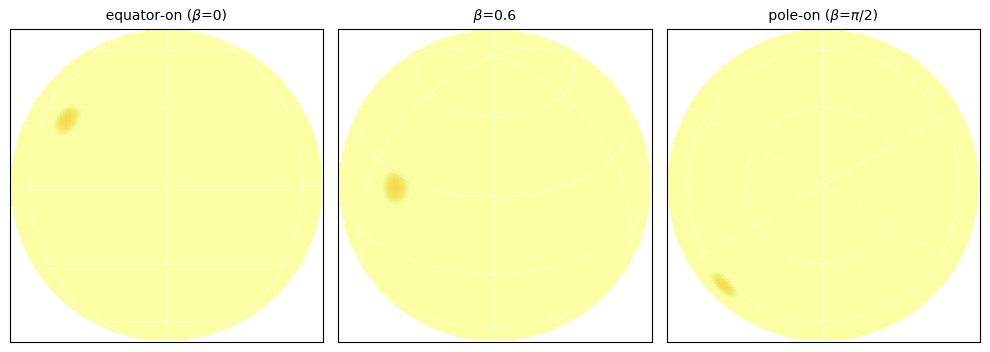

In [2]:
L = 20
star = jm.generate_spot(lat_deg=25, lon_deg=315, radius_deg=15,
                        l_max=L, contrast=0.8)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, beta, label in zip(axes, [0.0, 0.6, np.pi/2],
                           ["equator-on ($\\beta$=0)", "$\\beta$=0.6",
                            "pole-on ($\\beta$=$\\pi$/2)"]):
    show_star(ax, star, L, beta, label)
plt.tight_layout()

## Watching it rotate

The forward model is driven by rotation, so let's see one full spin. Each
frame is the visible hemisphere at a later rotation phase (an animated
version is in `examples/spin_animation_demo.py`):

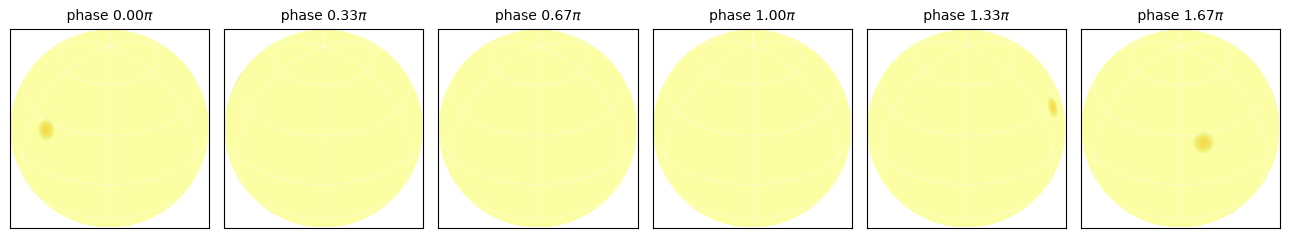

In [3]:
phases = np.linspace(0, 2*np.pi, 6, endpoint=False)
fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
for ax, t in zip(axes, phases):
    show_star(ax, star, L, 0.6, f"phase {t/np.pi:.2f}$\\pi$", t=t)
plt.tight_layout()

The spot crosses the visible disk and disappears around the limb — this is
what generates both the photocenter wobble and the brightness dip.

## Spot sizes

Spot radii are often quoted as a fraction of the stellar radius
$R_\mathrm{spot}/R_\star$; `rfrac_to_deg` converts that to the angular cap
radius used by `generate_spot`. Sizes from a large sunspot group to the
giant polar spots seen on M dwarfs and RS CVn stars:

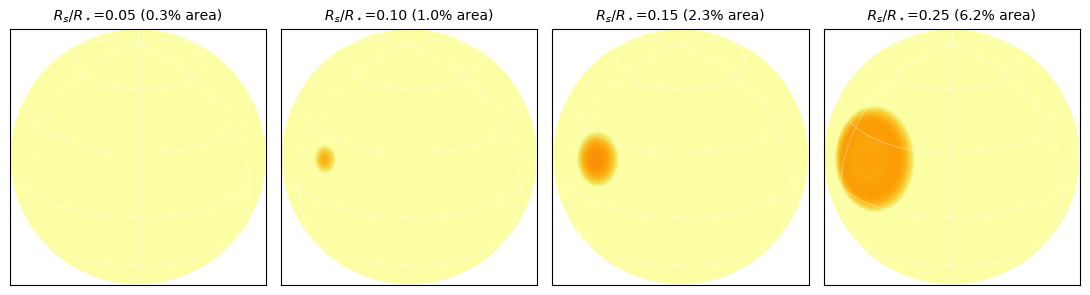

In [4]:
fracs = [0.05, 0.10, 0.15, 0.25]
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, rf in zip(axes, fracs):
    s = jm.generate_spot(20, 315, jm.rfrac_to_deg(rf), L)
    show_star(ax, s, L, 0.5,
              f"$R_s/R_\\star$={rf:.2f} ({jm.spot_area_fraction(jm.rfrac_to_deg(rf))*100:.1f}% area)")
plt.tight_layout()

## Spotted stars with several spots and fine texture

`multispot_surface` combines any number of spots and can sprinkle in random
small-scale structure (drawn from the same smoothness prior later used for
reconstruction) to emulate unresolved active regions:

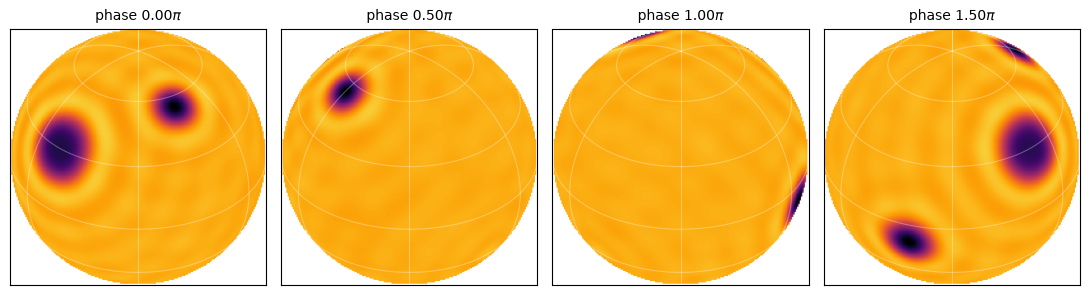

In [5]:
spots = [(30, 315, 14.0), (55, 30, 9.0), (-10, 250, 11.0)]
star3 = jm.multispot_surface(spots, l_max=L, texture_amplitude=0.004,
                             texture_seed=1)
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, t in zip(axes, np.linspace(0, 2*np.pi, 4, endpoint=False)):
    show_star(ax, star3, L, 0.6, f"phase {t/np.pi:.2f}$\\pi$", t=t)
plt.tight_layout()

## Under the hood: the coefficient vector

Everything above is a complex coefficient vector with real-surface
symmetry. Its per-degree power falls off with $l$ — large spots live at low
degree, fine texture at high degree — which is exactly the prior knowledge
the reconstruction uses.

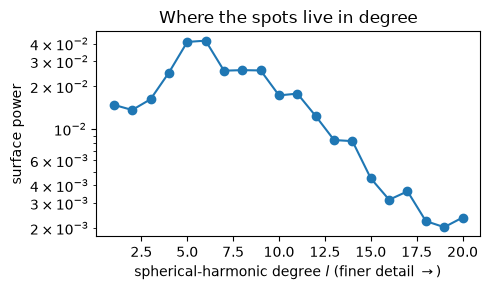

In [6]:
sh = jm.SHIndexer(L)
power = [np.sum(np.abs(star3[sh.get_l_indices(l)])**2) for l in range(1, L+1)]
plt.figure(figsize=(5, 3))
plt.semilogy(range(1, L+1), power, "o-")
plt.xlabel("spherical-harmonic degree $l$ (finer detail $\\rightarrow$)")
plt.ylabel("surface power")
plt.title("Where the spots live in degree")
plt.tight_layout()